Data Set Information:
The dataset contains 9568 data points collected from a Combined Cycle Power Plant over 6 years (2006-2011), when the power plant was set to work with full load. Features consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (PE) of the plant.


In [1]:
#import libraries
import pandas as pd
import numpy as np

In [2]:
#Import dataset
df=pd.read_csv('/home/oem/Downloads/Power Plant Data.csv')

In [3]:
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [4]:
#Define x and y(independent and dependent variable)
x=df.drop('PE',axis=1).values #drop all columns except depenedent variable PE
y=df['PE'].values

In [5]:
#split the dataset in training and testing set
from sklearn.model_selection import train_test_split

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.3, random_state=45)

In [7]:
#train the model on the training set
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)#fit the model to linear regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
#predict the test set result and see if we are getting the accurate results
y_pred = lr.predict(x_test)

In [9]:
print(y_pred)

[438.64642278 434.40431802 461.15558827 ... 463.80711134 474.06142868
 447.8010435 ]


In [10]:
#take the values of first row in x and compare our predicted y values with actual y value
lr.predict([[8.34,40.77,1010.84,90.01]])

array([477.170956])

In [11]:
#inorder to further evaluate the accuracy of our predicted value, evaluate using r2score
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9306851488677036

Text(0.5, 1.0, 'Actual vs predicted')

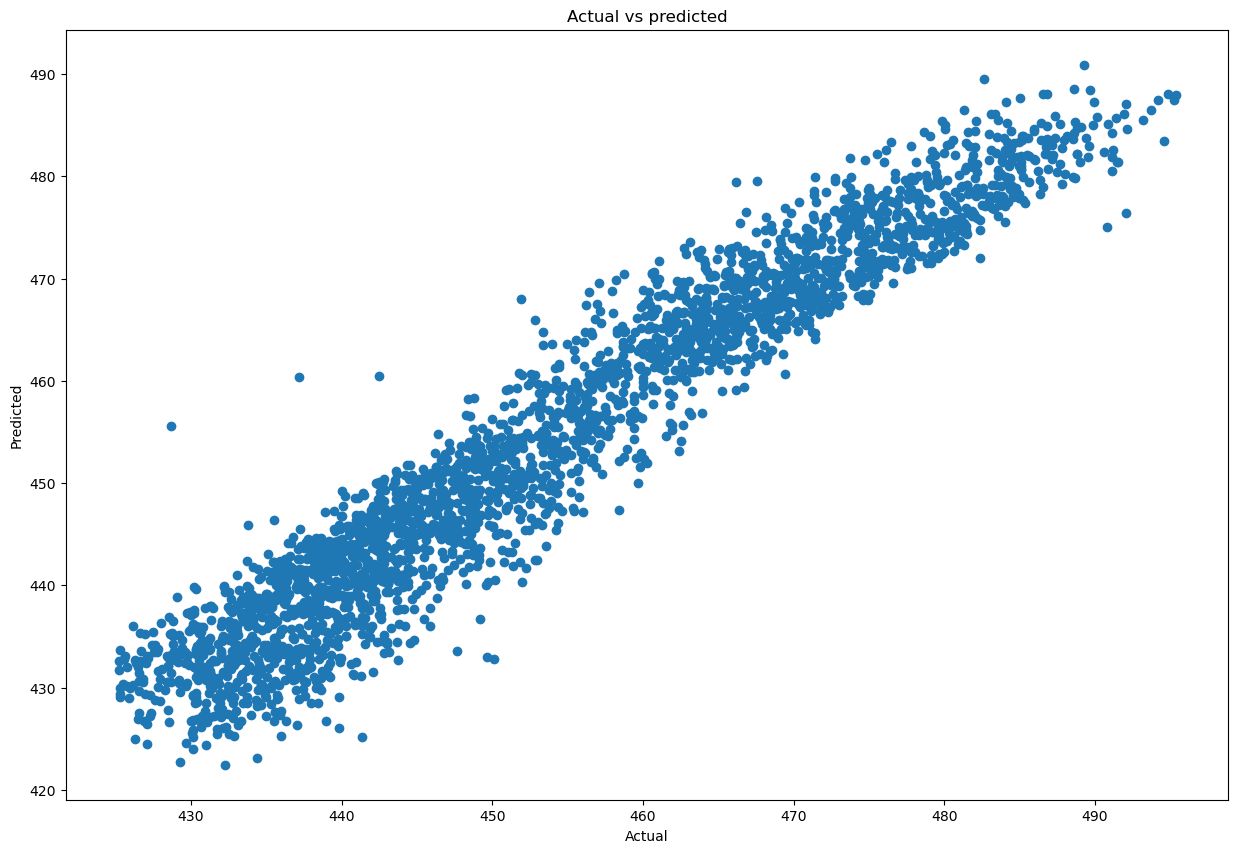

In [12]:
#then we visualize the predicted results
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs predicted')

#here we see that they are pretty close enough

In [13]:
#we print the predicted values of our model
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted value':y_pred})
pred_df

,Actual Value,Predicted value
0,444.68,438.646423
1,444.51,434.404318
2,462.96,461.155588
3,450.89,447.401804
4,449.01,441.910373
...,...,...
2866,431.77,430.930387
2867,439.74,438.952351
2868,463.10,463.807111
2869,471.96,474.061429
